# Feature Engineering

In [0]:
# Core Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
df_spark = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/Cars_Datasets_2025_cleaned_delta")
df_FE = df_spark.toPandas()

## Create features

In [0]:
# Calculate how much power you get for every unit of engine displacement
df_FE['HP_per_CC'] = df_FE['HorsePower'] / df_FE['cc_battery_capacity']

# Calculate the cost of 1 unit of Horsepower
df_FE['Price_per_HP'] = df_FE['cars_prices'] / df_FE['HorsePower']

# How many units of HP are used to shave off 1 second of acceleration
df_FE['HP_Acceleration_Effectiveness'] = df_FE['HorsePower'] / df_FE['performance_0_100_kmh']

# Price distributed per passenger capacity
df_FE['Price_per_Seat'] = df_FE['cars_prices'] / df_FE['Seats']

In [0]:
def extract_cylinders(engine_str):
    match = re.search(r'[VI](\d+)', engine_str)
    return int(match.group(1)) if match else 4  # Default to 4 if not specified (Average)

df_FE['Cylinders'] = df_FE['Engines'].apply(extract_cylinders)

In [0]:
# Define price tiers
bins = [0, 20000, 50000, 100000, float('inf')]
labels = ['Budget', 'Mid-Range', 'Luxury', 'Supercar']

df_FE['Price_Category'] = pd.cut(df_FE['cars_prices'], bins=bins, labels=labels)

In [0]:
# Apply log transformation to the price
df_FE['Log_Price'] = np.log1p(df_FE['cars_prices'])

In [0]:
df_FE_log = df_FE.drop(['cars_prices'], axis=1)

In [0]:
df_FE = df_FE.drop(['Log_Price'], axis=1)

In [0]:
display(df_FE)

company_names,cars_names,Engines,cc_battery_capacity,HorsePower,total_speed,performance_0_100_kmh,cars_prices,fuel_types,Seats,Torque,HP_per_CC,Price_per_HP,HP_Acceleration_Effectiveness,Price_per_Seat,Cylinders,Price_Category
FORD,KA+,1.2L Petrol,1200,77,165,10.5,13500,Petrol,5,120,0.06416666666666666,175.32467532467533,7.333333333333333,2700.0,4,Budget
TOYOTA,GR SUPRA,I4,2998,382,250,4.1,53900,Petrol,2,500,0.12741827885256837,141.09947643979058,93.17073170731707,26950.0,4,Luxury
TOYOTA,TOYOTA 86,BOXER-4,1998,205,226,6.4,27000,Petrol,2,205,0.10260260260260261,131.70731707317074,32.03125,13500.0,4,Mid-Range
TOYOTA,TOYOTA GR86,BOXER-4,2387,228,226,5.6,30000,Petrol,4,250,0.09551738583996648,131.57894736842104,40.714285714285715,7500.0,4,Mid-Range
TOYOTA,TOYOTA LAND CRUISER,V8,5663,381,220,6.7,85000,Diesel,7,500,0.0672788274766025,223.0971128608924,56.865671641791046,12142.857142857143,8,Luxury
TOYOTA,TOYOTA SEQUOIA,V8,5663,381,200,6.9,50000,Petrol,7,651,0.0672788274766025,131.23359580052494,55.21739130434782,7142.857142857143,8,Mid-Range
NISSAN,GT-R,V6,3799,600,315,2.9,113000,Petrol,4,637,0.1579362990260595,188.33333333333334,206.89655172413794,28250.0,6,Supercar
NISSAN,370Z,V6,3696,332,250,4.7,30000,Petrol,2,366,0.08982683982683982,90.36144578313252,70.63829787234042,15000.0,6,Mid-Range
NISSAN,Z PROTO,V6,2998,400,290,4.1,40000,Petrol,2,475,0.133422281521014,100.0,97.5609756097561,20000.0,6,Mid-Range
NISSAN,ALTIMA,I4,2488,188,225,7.3,25000,Petrol,5,380,0.07556270096463022,132.9787234042553,25.753424657534246,5000.0,4,Mid-Range


In [0]:
display(df_FE_log)

company_names,cars_names,Engines,cc_battery_capacity,HorsePower,total_speed,performance_0_100_kmh,fuel_types,Seats,Torque,HP_per_CC,Price_per_HP,HP_Acceleration_Effectiveness,Price_per_Seat,Cylinders,Price_Category,Log_Price
FORD,KA+,1.2L Petrol,1200,77,165,10.5,Petrol,5,120,0.06416666666666666,175.32467532467533,7.333333333333333,2700.0,4,Budget,9.510519035757246
TOYOTA,GR SUPRA,I4,2998,382,250,4.1,Petrol,2,500,0.12741827885256837,141.09947643979058,93.17073170731707,26950.0,4,Luxury,10.894904309600681
TOYOTA,TOYOTA 86,BOXER-4,1998,205,226,6.4,Petrol,2,205,0.10260260260260261,131.70731707317074,32.03125,13500.0,4,Mid-Range,10.203629181337648
TOYOTA,TOYOTA GR86,BOXER-4,2387,228,226,5.6,Petrol,4,250,0.09551738583996648,131.57894736842104,40.714285714285715,7500.0,4,Mid-Range,10.308985993422082
TOYOTA,TOYOTA LAND CRUISER,V8,5663,381,220,6.7,Diesel,7,500,0.0672788274766025,223.0971128608924,56.865671641791046,12142.857142857143,8,Luxury,11.350418300109132
TOYOTA,TOYOTA SEQUOIA,V8,5663,381,200,6.9,Petrol,7,651,0.0672788274766025,131.23359580052494,55.21739130434782,7142.857142857143,8,Mid-Range,10.819798284210286
NISSAN,GT-R,V6,3799,600,315,2.9,Petrol,4,637,0.1579362990260595,188.33333333333334,206.89655172413794,28250.0,6,Supercar,11.635151947212842
NISSAN,370Z,V6,3696,332,250,4.7,Petrol,2,366,0.08982683982683982,90.36144578313252,70.63829787234042,15000.0,6,Mid-Range,10.308985993422082
NISSAN,Z PROTO,V6,2998,400,290,4.1,Petrol,2,475,0.133422281521014,100.0,97.5609756097561,20000.0,6,Mid-Range,10.596659732783579
NISSAN,ALTIMA,I4,2488,188,225,7.3,Petrol,5,380,0.07556270096463022,132.9787234042553,25.753424657534246,5000.0,4,Mid-Range,10.12667110305036


Correlation MAtrix of new features

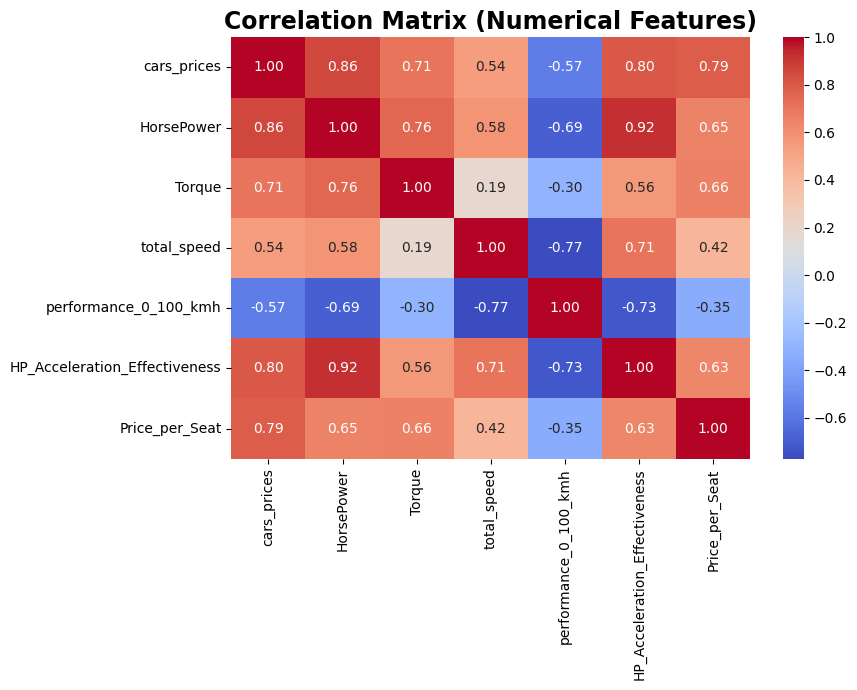

In [0]:
plt.figure(figsize=(9,7))
corr = df_FE[['cars_prices', 'HorsePower', 'Torque', 'total_speed', 'performance_0_100_kmh', 'HP_Acceleration_Effectiveness', 'Price_per_Seat']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Numerical Features)', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show() 

In [0]:
df_spark_FE = spark.createDataFrame(df_FE)
df_spark_FE_log = spark.createDataFrame(df_FE_log)
df_spark_FE.write.format("delta").mode("overwrite").save("/Volumes/workspace/default/ai-enhanced_project/Cars_Datasets_2025_FE_delta3")
df_spark_FE_log.write.format("delta").mode("overwrite").save("/Volumes/workspace/default/ai-enhanced_project/Cars_Datasets_2025_FE_delta2_log")

In [0]:
df_FE.to_csv("/Volumes/workspace/default/ai-enhanced_project/Cars_Datasets_2025_FE.csv", index=False)